In [10]:
# Core
import json
import numpy as np
import pandas as pd
import joblib

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# PyTorch (replaces TensorFlow/Keras)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import optuna
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error


In [3]:
# Device setup (PyTorch equivalent of TF GPU check)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)


Using device: cuda
GPU Name: NVIDIA GeForce GTX 1650
CUDA Version: 13.0


In [4]:
# Load the dataset
url = '../data/raw/parkinsons_updrs.data.csv'
data = pd.read_csv(url)

# Drop unnecessary columns
data = data.drop(columns=['subject#', 'test_time'])

# Separate features and targets
X = data.drop(columns=['motor_UPDRS', 'total_UPDRS'])
y = data[['motor_UPDRS', 'total_UPDRS']]

# Split the data
X_trainVal_raw, X_test_raw, y_trainVal, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainVal_raw, y_trainVal, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)

# Transform everything else
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)
X_trainVal = scaler.transform(X_trainVal_raw)

feature_names = X.columns

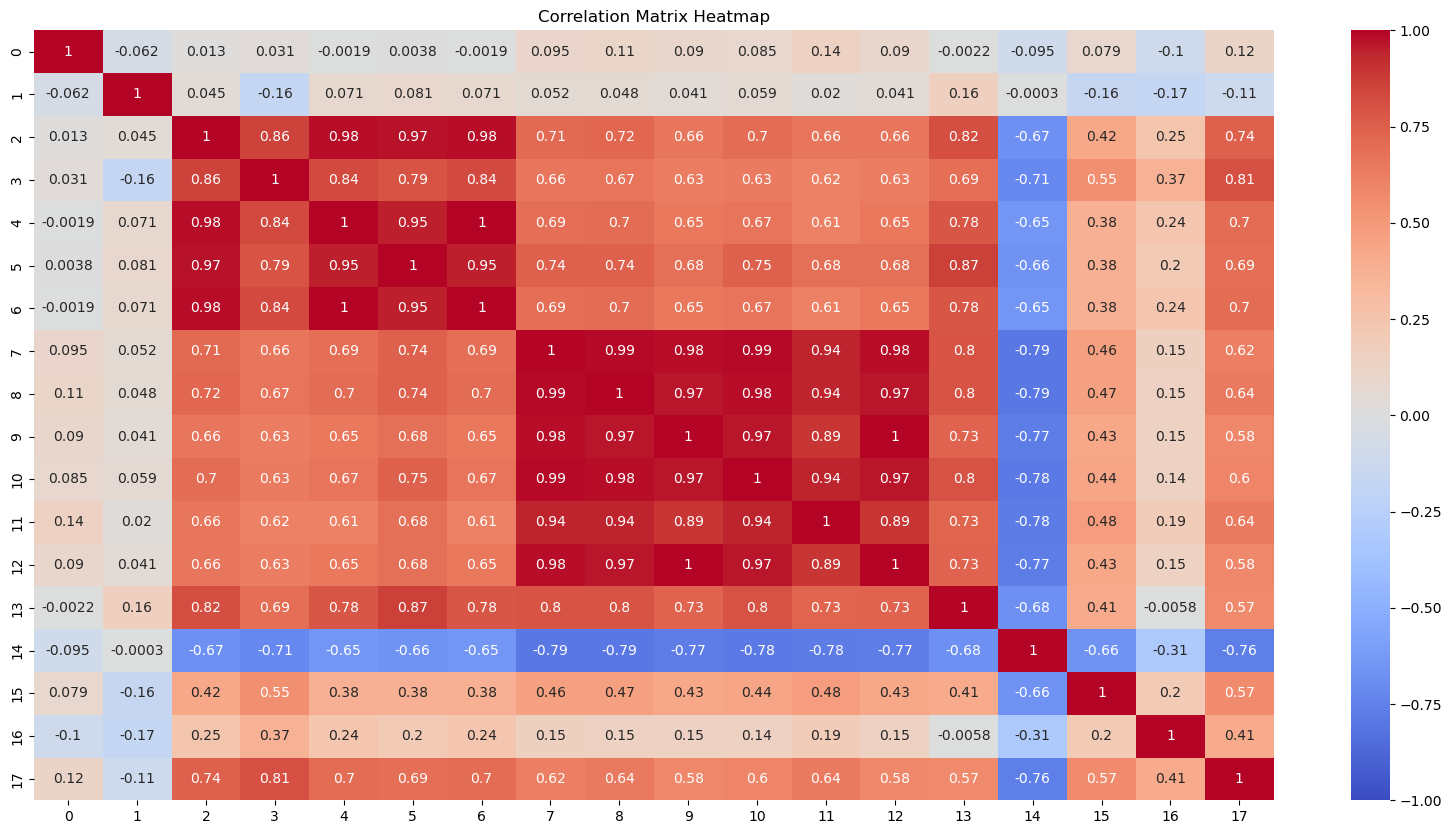

In [6]:
corr_matrix = pd.DataFrame(X_train).corr()

plt.figure(figsize=(20, 10))  # Adjust the figure size if necessary
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

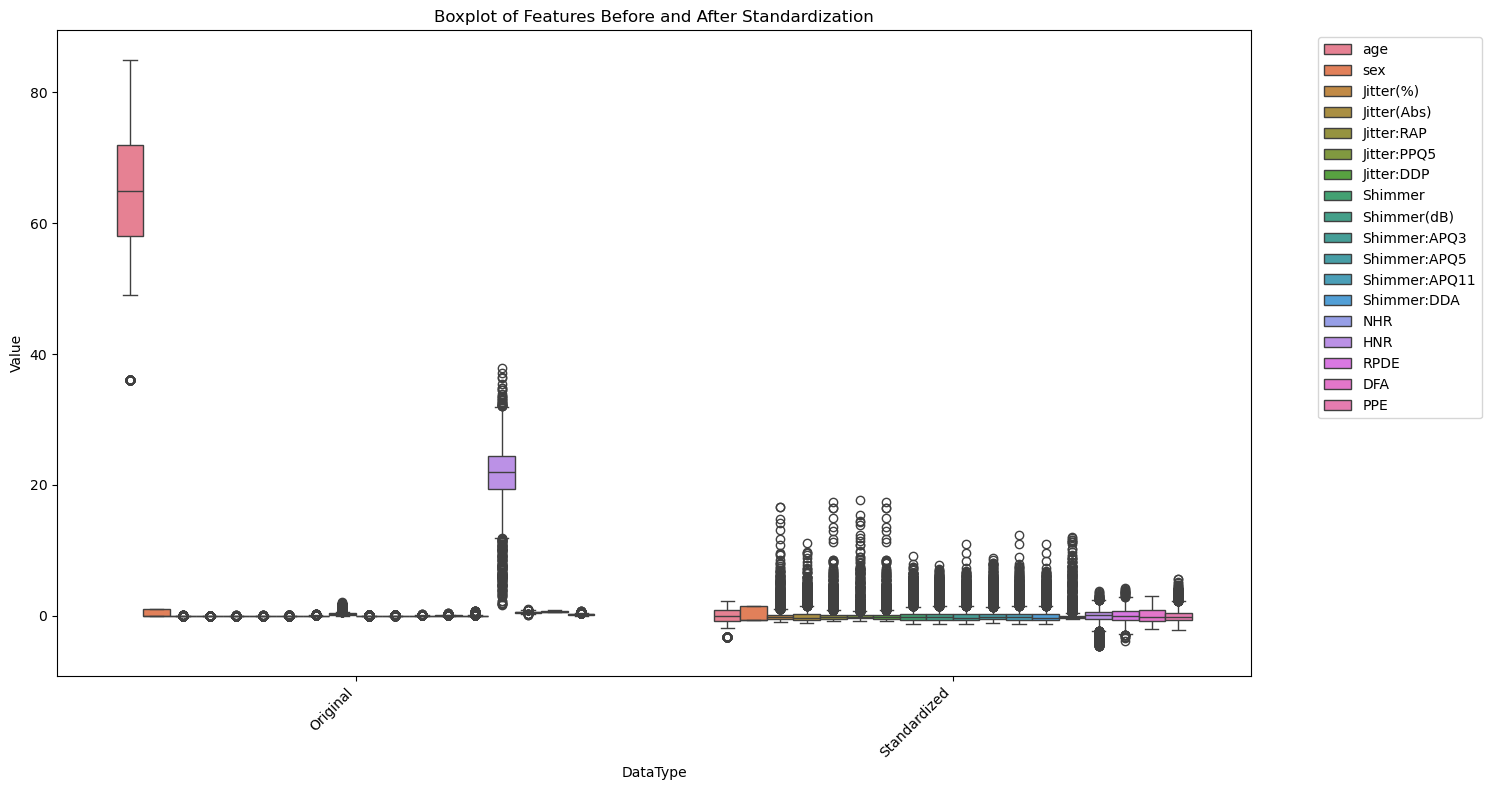

In [7]:
def plot_boxplots(original_data, scaled_data, feature_names):
    df_original = pd.DataFrame(original_data, columns=feature_names)
    df_scaled = pd.DataFrame(scaled_data, columns=feature_names)

    df_original['DataType'] = 'Original'
    df_scaled['DataType'] = 'Standardized'

    df_combined = pd.concat([df_original, df_scaled], ignore_index=True)

    plt.figure(figsize=(15, 8))
    # Melt the DataFrame to long format for seaborn
    df_melted = df_combined.melt(id_vars='DataType', var_name='Feature', value_name='Value')
    sns.boxplot(data=df_melted, x='DataType', y='Value', hue='Feature') # Use 'Value' for y-axis
    plt.title('Boxplot of Features Before and After Standardization')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

# Assuming feature_names is a list of your feature names
X_processed_for_plot = StandardScaler().fit_transform(X)
plot_boxplots(X, X_processed_for_plot, feature_names)

In [8]:
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_val_scaled   = y_scaler.transform(y_val)
y_trainVal_scaled = y_scaler.transform(y_trainVal)

In [11]:
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_val.npy", X_val)
np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/X_trainVal.npy", X_trainVal)

np.save("../data/processed/y_train.npy", y_train_scaled)
np.save("../data/processed/y_val.npy", y_val_scaled)
np.save("../data/processed/y_test.npy", y_test.values)
np.save("../data/processed/y_trainVal.npy", y_trainVal_scaled)

# Save feature names
with open("../data/processed/feature_names.json", "w") as f:
    json.dump(list(feature_names), f)

# Save scalers
joblib.dump(scaler, "../data/processed/X_scaler.pkl")
joblib.dump(y_scaler, "../data/processed/y_scaler.pkl")

print("✅ Dataset frozen. No more re-splitting ever again.")

✅ Dataset frozen. No more re-splitting ever again.
